# Face Analysis Debug Notebook

Analyze face detection results from sim_bench.db for specific images.

## Setup

In [87]:
import sqlite3
import json
import io
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image, ImageDraw, ImageOps
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Images to analyze
IMAGE_NAMES = [
    '20250822_183651.jpg',
    '20250822_112359.jpg',
    '20250824_163017.jpg',
    '20250822_112331.jpg',
    '20250822_121053.jpg'




    # '20250822_193451.jpg',
    # '20250822_112359.jpg',
    # '20250824_152151.jpg',
    # '20250822_192352.jpg',
    # '20250824_154340.jpg',
    # '20250822_112359.jpg',
    # '20250822_122632.jpg',
    # '20250822_123347.jpg'
]

# Connect to database (in user home directory)
db_path = Path.home() / '.sim_bench' / 'sim_bench.db'
conn = sqlite3.connect(str(db_path))
cursor = conn.cursor()

print(f"Connected to database: {db_path}")
print(f"Analyzing {len(IMAGE_NAMES)} images")

Connected to database: C:\Users\Jonathan Hexner\.sim_bench\sim_bench.db
Analyzing 5 images


## Query Functions

In [88]:
def get_face_detections(image_name):
    """Get face detections with landmarks and bboxes from UniversalCache."""
    query = """
    SELECT data_blob 
    FROM universal_cache 
    WHERE image_path LIKE ? AND feature_type = 'insightface_detection'
    """
    cursor.execute(query, (f'%{image_name}',))
    result = cursor.fetchone()
    
    if result is None:
        return None
    
    data = json.loads(result[0].decode('utf-8'))
    return data

def get_face_embeddings(image_name):
    """Get face embeddings from UniversalCache."""
    query = """
    SELECT image_path, data_blob 
    FROM universal_cache 
    WHERE image_path LIKE ? AND feature_type = 'face_embedding'
    """
    cursor.execute(query, (f'%{image_name}%',))
    results = cursor.fetchall()
    
    embeddings = {}
    for path, blob in results:
        # Deserialize numpy embedding
        buffer = io.BytesIO(blob)
        embedding = np.load(buffer, allow_pickle=False)
        embeddings[path] = embedding
    
    return embeddings

def get_face_scores(image_name):
    """Get face scores from PipelineResult.image_metrics."""
    query = """
    SELECT image_metrics 
    FROM pipeline_results 
    ORDER BY id DESC 
    LIMIT 1
    """
    cursor.execute(query)
    result = cursor.fetchone()
    
    if result is None:
        return None
    
    all_metrics = json.loads(result[0])
    
    for path, metrics in all_metrics.items():
        if image_name in path:
            return metrics
    
    return None

def find_image_path(image_name):
    """Find full image path from database."""
    query = """
    SELECT DISTINCT image_path 
    FROM universal_cache 
    WHERE image_path LIKE ?
    LIMIT 1
    """
    cursor.execute(query, (f'%{image_name}',))
    result = cursor.fetchone()
    return result[0] if result else None

print("Query functions defined")

Query functions defined


## Load and Analyze Face Data

In [89]:
# Collect data for all images
face_data = {}

for img_name in IMAGE_NAMES:
    full_path = find_image_path(img_name)
    detections = get_face_detections(img_name)
    embeddings = get_face_embeddings(img_name)
    scores = get_face_scores(img_name)
    
    face_data[img_name] = {
        'path': full_path,
        'detections': detections,
        'embeddings': embeddings,
        'scores': scores
    }
    
    num_faces = len(detections['faces']) if detections else 0
    print(f"{img_name}: {num_faces} faces detected")

20250822_183651.jpg: 1 faces detected
20250822_112359.jpg: 9 faces detected
20250824_163017.jpg: 1 faces detected
20250822_112331.jpg: 3 faces detected
20250822_121053.jpg: 3 faces detected


## Visualize Faces with Bounding Boxes and Landmarks

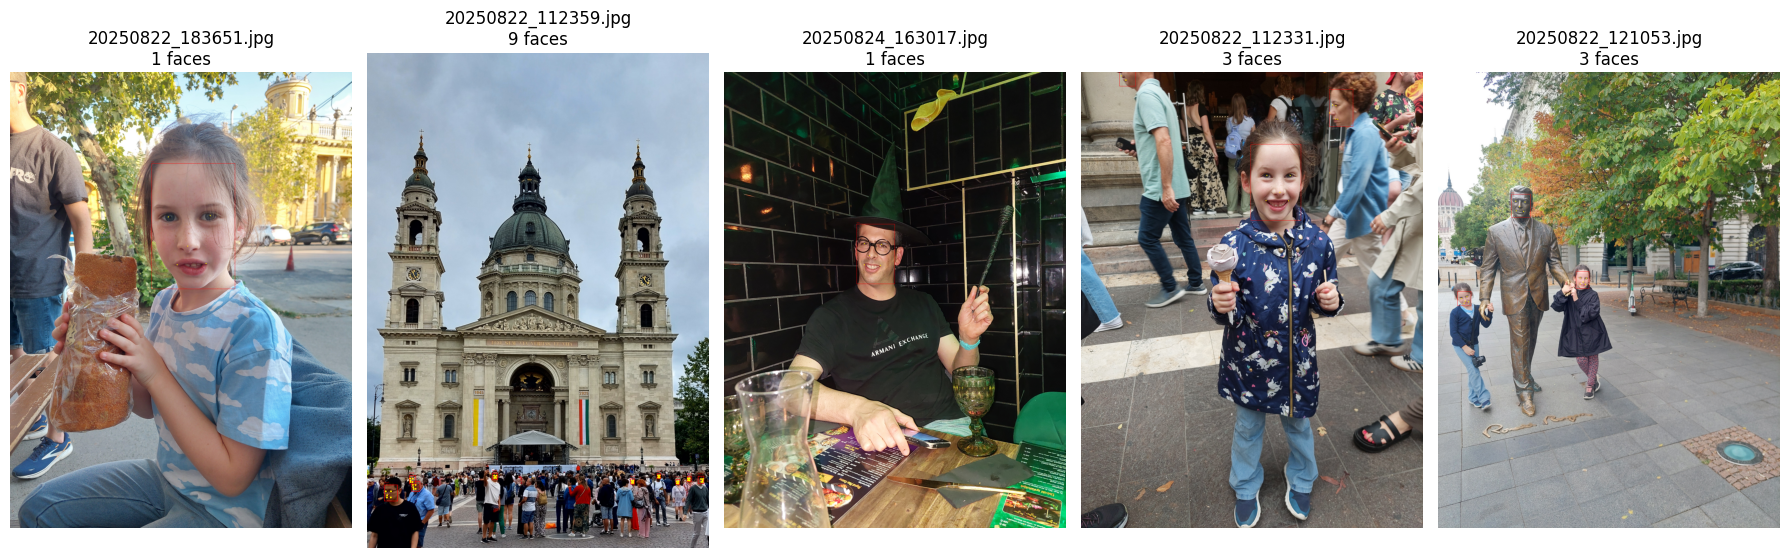

In [91]:
def draw_faces_on_image(image_path, detections):
    """Draw bounding boxes and landmarks on image."""
    img = Image.open(image_path)
    img = ImageOps.exif_transpose(img)
    draw = ImageDraw.Draw(img)
    
    faces = detections.get('faces', [])
    
    for i, face in enumerate(faces):
        bbox = face['bbox']
        landmarks = np.array(face['landmarks'])
        
        # Draw bounding box
        x1, y1 = bbox['x_px'], bbox['y_px']
        x2, y2 = x1 + bbox['w_px'], y1 + bbox['h_px']
        draw.rectangle([x1, y1, x2, y2], outline='red', width=3)
        
        # Draw landmarks (5 points)
        for j, (x, y) in enumerate(landmarks):
            draw.ellipse([x-5, y-5, x+5, y+5], fill='yellow', outline='orange')
        
        # Draw face index
        draw.text((x1, y1-20), f"Face {i}", fill='red')
    
    return img

# Visualize each image
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for idx, img_name in enumerate(IMAGE_NAMES):
    data = face_data[img_name]
    
    if data['path'] and data['detections']:
        img_with_faces = draw_faces_on_image(data['path'], data['detections'])
        axes[idx].imshow(img_with_faces)
        axes[idx].set_title(f"{img_name}\n{len(data['detections']['faces'])} faces")
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[idx].set_title(img_name)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Cropped Faces with Landmarks

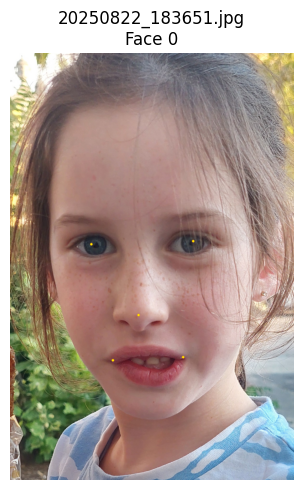

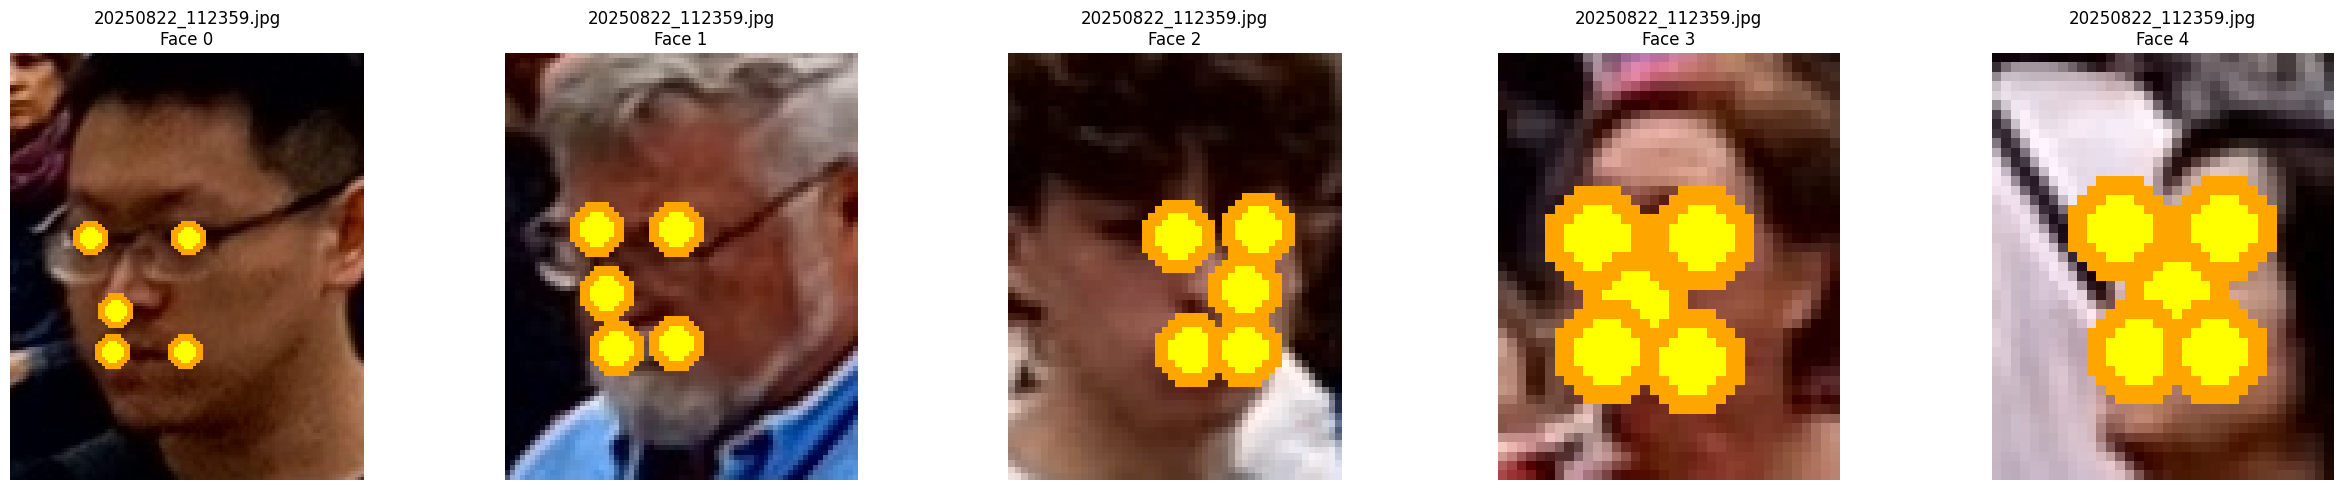

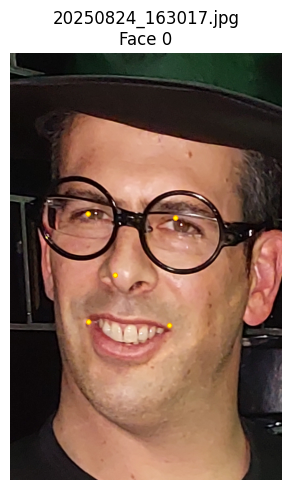

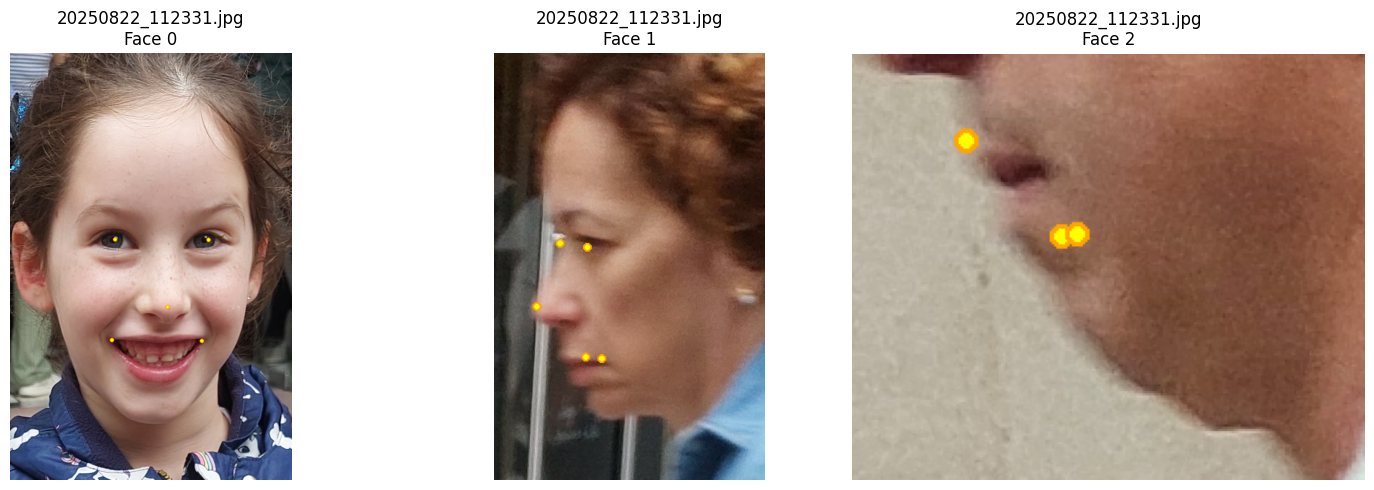

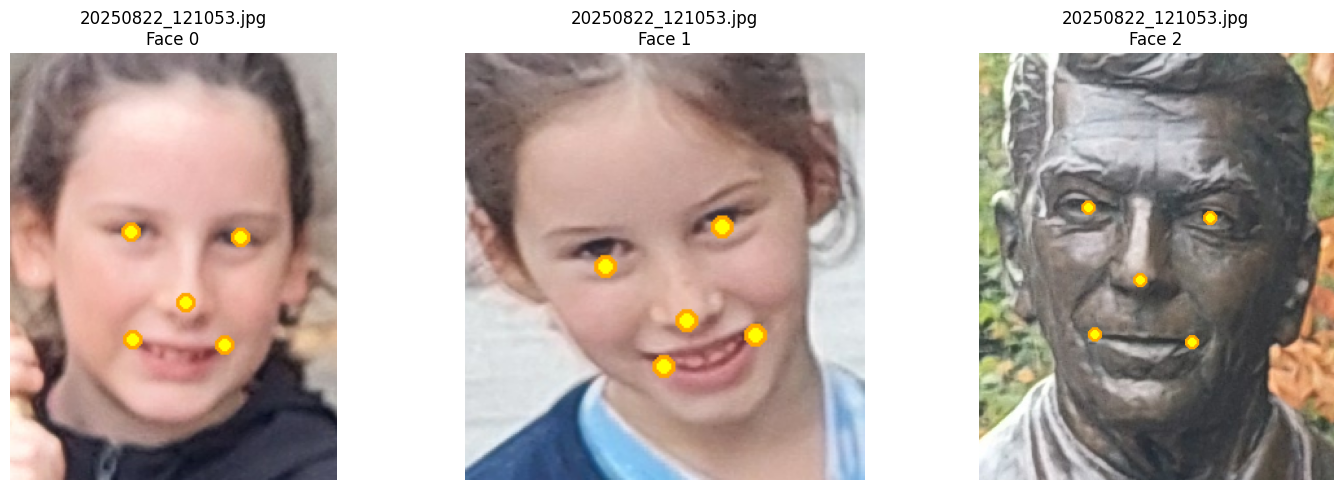

In [92]:
# Display cropped faces with landmarks
for img_name in IMAGE_NAMES:
    data = face_data[img_name]
    
    if data['path'] and data['detections']:
        faces = data['detections']['faces'][0:5]
        num_faces = len(faces)
        
        if num_faces == 0:
            continue
        
        # Load original image
        img = Image.open(data['path'])
        img = ImageOps.exif_transpose(img)
        
        # Create subplot for this image's faces
        fig, axes = plt.subplots(1, num_faces, figsize=(5*num_faces, 5))
        if num_faces == 1:
            axes = [axes]
        
        for idx, face in enumerate(faces):
            bbox = face['bbox']
            landmarks = np.array(face['landmarks'])
            
            # Crop face with padding
            x1, y1 = bbox['x_px'], bbox['y_px']
            x2, y2 = x1 + bbox['w_px'], y1 + bbox['h_px']
            
            # Add 20% padding
            pad_x = int(bbox['w_px'] * 0.2)
            pad_y = int(bbox['h_px'] * 0.2)
            x1_pad = max(0, x1 - pad_x)
            y1_pad = max(0, y1 - pad_y)
            x2_pad = min(img.width, x2 + pad_x)
            y2_pad = min(img.height, y2 + pad_y)
            
            # Crop and draw
            face_crop = img.crop((x1_pad, y1_pad, x2_pad, y2_pad))
            draw = ImageDraw.Draw(face_crop)
            
            # Adjust landmark coordinates to cropped image
            for j, (x, y) in enumerate(landmarks):
                x_adj = x - x1_pad
                y_adj = y - y1_pad
                draw.ellipse([x_adj-5, y_adj-5, x_adj+5, y_adj+5], fill='yellow', outline='orange', width=2)
            
            # Display
            axes[idx].imshow(face_crop)
            axes[idx].set_title(f"{img_name}\nFace {idx}")
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()

## Face Metrics Summary

In [93]:
# Build summary table with derived metrics
summary_rows = []

for img_name in IMAGE_NAMES:
    data = face_data[img_name]
    detections = data['detections']
    scores = data['scores']
    
    if detections and scores:
        faces = detections['faces']
        
        # Get image dimensions once per image
        img_width = None
        img_height = None
        if data['path']:
            img = Image.open(data['path'])
        img = ImageOps.exif_transpose(img)
        img_width = img.width
        img_height = img.height
        
        for i, face in enumerate(faces):
            bbox = face['bbox']
            landmarks = np.array(face['landmarks'])
            face_size = bbox['w_px'] * bbox['h_px']
            
            # Extract landmark points
            left_eye = landmarks[0]
            right_eye = landmarks[1]
            nose = landmarks[2]
            
            # Calculate inter-eye distance
            inter_eye_dist = np.linalg.norm(right_eye - left_eye)
            
            # Face width from bbox
            face_width = bbox['w_px']
            
            # Face width to image width ratio
            face_width_ratio = face_width / img_width if img_width else 0
            
            # Ratio: inter_eye / face_width (frontal indicator)
            eye_width_ratio = inter_eye_dist / face_width if face_width > 0 else 0
            
            # Asymmetry: distance from nose to each eye
            dist_nose_left = np.linalg.norm(nose - left_eye)
            dist_nose_right = np.linalg.norm(nose - right_eye)
            asymmetry_ratio = max(dist_nose_left, dist_nose_right) / (min(dist_nose_left, dist_nose_right) + 1e-6)
            
            # Quality flags based on heuristics
            is_frontal = eye_width_ratio >= 0.20  # Threshold for frontal face
            is_symmetric = asymmetry_ratio < 1.8  # Threshold for symmetry
            is_large_enough = bbox['w_px'] >= 70  # Minimum face size
            
            pose_score = scores['face_pose_scores'][i] if scores.get('face_pose_scores') and i < len(scores['face_pose_scores']) else None
            eyes_score = scores['face_eyes_scores'][i] if scores.get('face_eyes_scores') and i < len(scores['face_eyes_scores']) else None
            smile_score = scores['face_smile_scores'][i] if scores.get('face_smile_scores') and i < len(scores['face_smile_scores']) else None
            
            summary_rows.append({
                'Image': img_name,
                'Face': i,
                'Size (px²)': face_size,
                'Width': bbox['w_px'],
                'Height': bbox['h_px'],
                'Face/Img': f"{face_width_ratio:.3f}",
                'Confidence': f"{face['confidence']:.3f}",
                'Inter-Eye': f"{inter_eye_dist:.1f}",
                'Eye/Width': f"{eye_width_ratio:.3f}",
                'Asymmetry': f"{asymmetry_ratio:.2f}",
                'Frontal?': '✓' if is_frontal else '✗',
                'Symmetric?': '✓' if is_symmetric else '✗',
                'Size OK?': '✓' if is_large_enough else '✗',
                'Pose Score': f"{pose_score:.3f}" if pose_score is not None else 'N/A',
                'Eyes Score': f"{eyes_score:.3f}" if eyes_score is not None else 'N/A',
                'Smile Score': f"{smile_score:.3f}" if smile_score is not None else 'N/A'
            })

df_summary = pd.DataFrame(summary_rows)
df_summary

,Image,Face,Size (px²),Width,Height,Face/Img,Confidence,Inter-Eye,Eye/Width,Asymmetry,Frontal?,Symmetric?,Size OK?,Pose Score,Eyes Score,Smile Score
0,20250822_183651.jpg,0,1079925,847,1275,0.244,0.798,425.2,0.502,1.08,✓,✓,✓,0.881,0.693,0.211
1,20250822_112359.jpg,0,7760,80,97,0.039,0.854,31.2,0.390,1.34,✓,✓,✓,0.527,0.554,0.163
2,20250822_112359.jpg,1,3162,51,62,0.025,0.666,16.4,0.322,1.46,✓,✓,✗,0.251,0.500,0.500
3,20250822_112359.jpg,2,1656,36,46,0.018,0.663,12.0,0.334,1.40,✓,✓,✗,0.414,0.500,0.500
4,20250822_112359.jpg,3,858,26,33,0.013,0.548,10.5,0.404,1.20,✓,✓,✗,0.756,0.500,0.500
5,20250822_112359.jpg,4,858,26,33,0.013,0.482,11.4,0.437,1.09,✓,✓,✗,0.500,0.500,0.500
6,20250822_112359.jpg,5,825,25,33,0.012,0.404,10.9,0.438,1.01,✓,✓,✗,0.500,0.500,0.500
7,20250822_112359.jpg,6,1320,33,40,0.016,0.358,13.8,0.419,1.06,✓,✓,✗,0.500,0.500,0.500
8,20250822_112359.jpg,7,768,24,32,0.012,0.334,10.1,0.420,1.06,✓,✓,✗,0.500,0.500,0.500
9,20250822_112359.jpg,8,2080,40,52,0.020,0.260,14.7,0.368,1.46,✓,✓,✗,0.500,0.500,0.500


## Landmark Coordinates

In [94]:
# Display landmark coordinates for each face
landmark_names = ['Left Eye', 'Right Eye', 'Nose', 'Left Mouth', 'Right Mouth']

for img_name in IMAGE_NAMES:
    data = face_data[img_name]
    detections = data['detections']
    
    if detections:
        print(f"\n{img_name}:")
        faces = detections['faces']
        
        for i, face in enumerate(faces):
            print(f"  Face {i}:")
            landmarks = np.array(face['landmarks'])
            for j, (x, y) in enumerate(landmarks):
                print(f"    {landmark_names[j]}: ({x:.1f}, {y:.1f})")


20250822_183651.jpg:
  Face 0:
    Left Eye: (1605.9, 1469.8)
    Right Eye: (2030.8, 1456.3)
    Nose: (1802.7, 1765.1)
    Left Mouth: (1695.0, 1954.2)
    Right Mouth: (1988.4, 1941.3)

20250822_112359.jpg:
  Face 0:
    Left Eye: (111.7, 2603.2)
    Right Eye: (142.9, 2603.3)
    Nose: (119.9, 2626.0)
    Left Mouth: (118.1, 2639.7)
    Right Mouth: (141.6, 2639.3)
  Face 1:
    Left Eye: (272.2, 2565.5)
    Right Eye: (288.6, 2565.1)
    Nose: (274.6, 2578.6)
    Left Mouth: (276.7, 2589.3)
    Right Mouth: (288.8, 2588.4)
  Face 2:
    Left Eye: (1982.4, 2530.0)
    Right Eye: (1994.4, 2529.7)
    Nose: (1992.2, 2538.9)
    Left Mouth: (1984.2, 2547.1)
    Right Mouth: (1993.0, 2547.1)
  Face 3:
    Left Eye: (1904.8, 2526.2)
    Right Eye: (1915.3, 2526.6)
    Nose: (1908.6, 2533.0)
    Left Mouth: (1905.7, 2538.8)
    Right Mouth: (1914.0, 2539.1)
  Face 4:
    Left Eye: (1570.3, 2540.4)
    Right Eye: (1581.7, 2540.2)
    Nose: (1576.7, 2547.0)
    Left Mouth: (1572.4, 2553.6

## Filtered High-Quality Faces

Only showing faces that pass all quality checks: Size OK, Frontal, and Symmetric

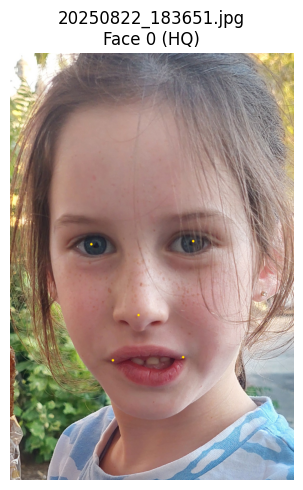

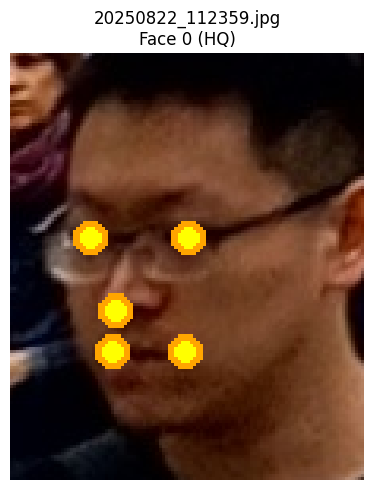

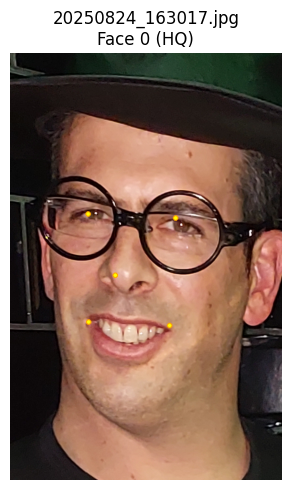

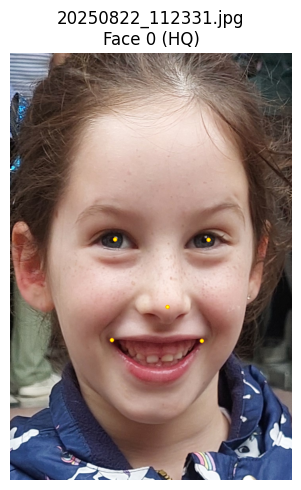

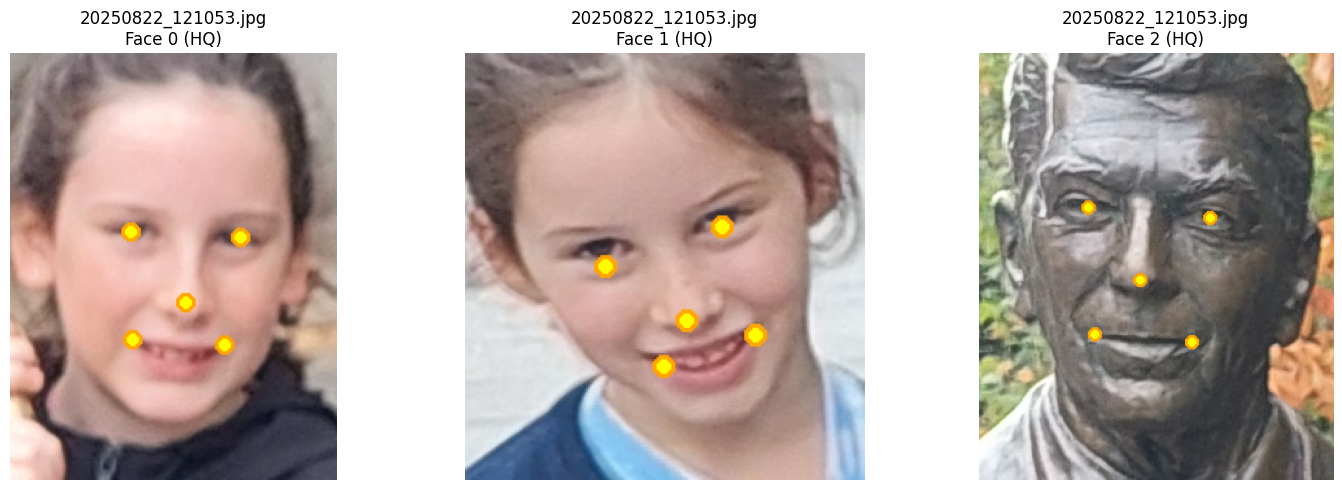

In [95]:
# Display filtered high-quality cropped faces with landmarks
for img_name in IMAGE_NAMES:
    data = face_data[img_name]
    
    if data['path'] and data['detections']:
        faces = data['detections']['faces']
        
        # Filter faces based on quality criteria
        filtered_faces = []
        for idx, face in enumerate(faces):
            bbox = face['bbox']
            landmarks = np.array(face['landmarks'])
            
            # Calculate quality metrics
            left_eye = landmarks[0]
            right_eye = landmarks[1]
            nose = landmarks[2]
            
            inter_eye_dist = np.linalg.norm(right_eye - left_eye)
            face_width = bbox['w_px']
            eye_width_ratio = inter_eye_dist / face_width if face_width > 0 else 0
            
            dist_nose_left = np.linalg.norm(nose - left_eye)
            dist_nose_right = np.linalg.norm(nose - right_eye)
            asymmetry_ratio = max(dist_nose_left, dist_nose_right) / (min(dist_nose_left, dist_nose_right) + 1e-6)
            
            # Apply filters
            is_frontal = eye_width_ratio >= 0.20
            is_symmetric = asymmetry_ratio < 1.8
            is_large_enough = bbox['w_px'] >= 70
            
            if is_frontal and is_symmetric and is_large_enough:
                filtered_faces.append((idx, face))
        
        if len(filtered_faces) == 0:
            continue
        
        # Load original image
        img = Image.open(data['path'])
        img = ImageOps.exif_transpose(img)
        
        # Create subplot
        fig, axes = plt.subplots(1, len(filtered_faces), figsize=(5*len(filtered_faces), 5))
        if len(filtered_faces) == 1:
            axes = [axes]
        
        for plot_idx, (face_idx, face) in enumerate(filtered_faces):
            bbox = face['bbox']
            landmarks = np.array(face['landmarks'])
            
            # Crop with padding
            x1, y1 = bbox['x_px'], bbox['y_px']
            x2, y2 = x1 + bbox['w_px'], y1 + bbox['h_px']
            pad_x = int(bbox['w_px'] * 0.2)
            pad_y = int(bbox['h_px'] * 0.2)
            x1_pad = max(0, x1 - pad_x)
            y1_pad = max(0, y1 - pad_y)
            x2_pad = min(img.width, x2 + pad_x)
            y2_pad = min(img.height, y2 + pad_y)
            
            face_crop = img.crop((x1_pad, y1_pad, x2_pad, y2_pad))
            draw = ImageDraw.Draw(face_crop)
            
            # Draw landmarks
            for j, (x, y) in enumerate(landmarks):
                x_adj = x - x1_pad
                y_adj = y - y1_pad
                draw.ellipse([x_adj-5, y_adj-5, x_adj+5, y_adj+5], fill='yellow', outline='orange', width=2)
            
            axes[plot_idx].imshow(face_crop)
            axes[plot_idx].set_title(f"{img_name}\nFace {face_idx} (HQ)")
            axes[plot_idx].axis('off')
        
        plt.tight_layout()
        plt.show()

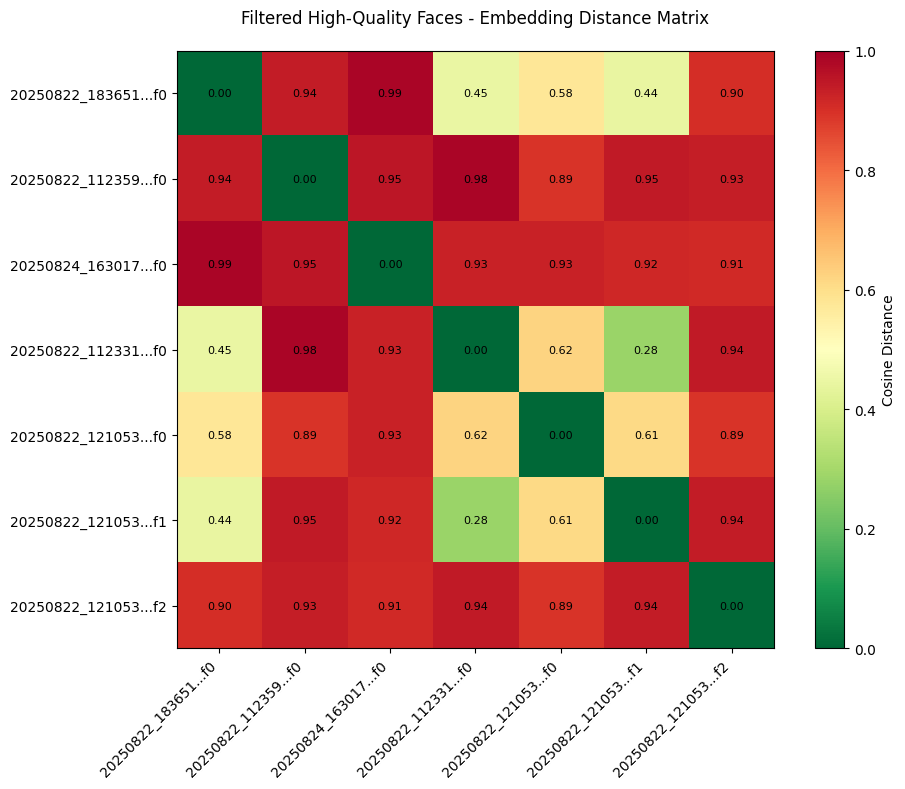


Filtered faces: 7
Lower distances = more similar faces


In [96]:
# Collect embeddings only from high-quality faces
filtered_embeddings = []
filtered_labels = []

for img_name in IMAGE_NAMES:
    data = face_data[img_name]
    detections = data['detections']
    embeddings = data['embeddings']
    
    if detections and embeddings:
        faces = detections['faces']
        
        for idx, face in enumerate(faces):
            bbox = face['bbox']
            landmarks = np.array(face['landmarks'])
            
            # Calculate quality metrics
            left_eye = landmarks[0]
            right_eye = landmarks[1]
            nose = landmarks[2]
            
            inter_eye_dist = np.linalg.norm(right_eye - left_eye)
            face_width = bbox['w_px']
            eye_width_ratio = inter_eye_dist / face_width if face_width > 0 else 0
            
            dist_nose_left = np.linalg.norm(nose - left_eye)
            dist_nose_right = np.linalg.norm(nose - right_eye)
            asymmetry_ratio = max(dist_nose_left, dist_nose_right) / (min(dist_nose_left, dist_nose_right) + 1e-6)
            
            # Apply filters
            is_frontal = eye_width_ratio >= 0.20
            is_symmetric = asymmetry_ratio < 1.8
            is_large_enough = bbox['w_px'] >= 70
            
            if is_frontal and is_symmetric and is_large_enough:
                # Get embedding for this face
                for path, embedding in embeddings.items():
                    if f'face_{idx}' in path:
                        filtered_embeddings.append(embedding)
                        filtered_labels.append(f"{img_name[:15]}...f{idx}")
                        break

# Calculate distance matrix for filtered faces
if len(filtered_embeddings) > 0:
    embeddings_matrix = np.vstack(filtered_embeddings)
    distance_matrix = cdist(embeddings_matrix, embeddings_matrix, metric='cosine')
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(distance_matrix, cmap='RdYlGn_r', vmin=0, vmax=1)
    
    ax.set_xticks(range(len(filtered_labels)))
    ax.set_yticks(range(len(filtered_labels)))
    ax.set_xticklabels(filtered_labels, rotation=45, ha='right')
    ax.set_yticklabels(filtered_labels)
    
    plt.colorbar(im, ax=ax, label='Cosine Distance')
    
    for i in range(len(filtered_labels)):
        for j in range(len(filtered_labels)):
            text = ax.text(j, i, f'{distance_matrix[i, j]:.2f}',
                          ha='center', va='center', color='black', fontsize=8)
    
    ax.set_title('Filtered High-Quality Faces - Embedding Distance Matrix', pad=20)
    plt.tight_layout()
    plt.show()
    
    print(f"\nFiltered faces: {len(filtered_embeddings)}")
    print(f"Lower distances = more similar faces")
else:
    print("No high-quality faces found matching all criteria")

## Face Embedding Distance Matrix

In [99]:
np.linalg.norm(embeddings_matrix[0])


1.0

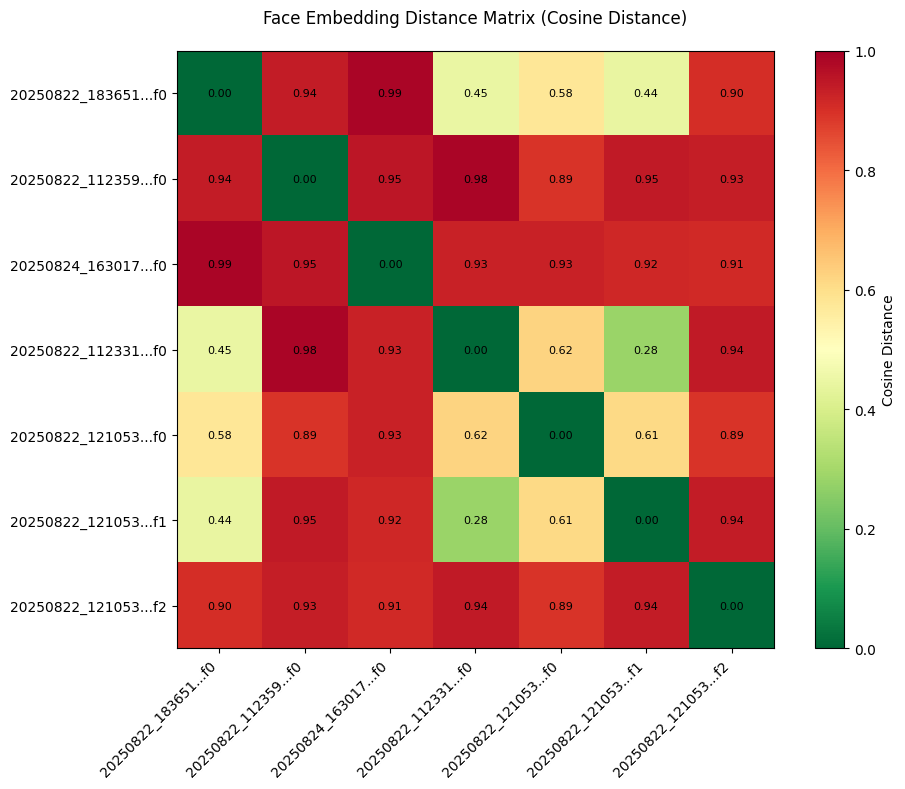


Distance matrix shape: (7, 7)
Lower distances = more similar faces


In [97]:
# Collect all embeddings
all_embeddings = []
labels = []

for img_name in IMAGE_NAMES:
    data = face_data[img_name]
    embeddings = data['embeddings']
    
    if embeddings:
        for path, embedding in embeddings.items():
            face_idx = path.split(':face_')[-1]
            all_embeddings.append(embedding)
            labels.append(f"{img_name[:15]}...f{face_idx}")

# Calculate distance matrix
if len(all_embeddings) > 0:
    embeddings_matrix = np.vstack(all_embeddings)
    distance_matrix = cdist(embeddings_matrix, embeddings_matrix, metric='cosine')
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(distance_matrix, cmap='RdYlGn_r', vmin=0, vmax=1)
    
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label='Cosine Distance')
    
    # Add distance values
    for i in range(len(labels)):
        for j in range(len(labels)):
            text = ax.text(j, i, f'{distance_matrix[i, j]:.2f}',
                          ha='center', va='center', color='black', fontsize=8)
    
    ax.set_title('Face Embedding Distance Matrix (Cosine Distance)', pad=20)
    plt.tight_layout()
    plt.show()
    
    print(f"\nDistance matrix shape: {distance_matrix.shape}")
    print(f"Lower distances = more similar faces")
else:
    print("No embeddings found")

## Close Connection

In [98]:
conn.close()
print("Database connection closed")

Database connection closed
